In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

.\Stocks.ipynb
.\Stocks_AMZN.csv


In [2]:
filepath = './Stocks_AMZN.csv'
data = pd.read_csv(filepath)
data = data.sort_values('Date')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-08-31,3408.989990,3495.000000,3405.000000,3450.959961,3450.959961,4185900
1,2020-09-01,3489.580078,3513.870117,3467.000000,3499.120117,3499.120117,3432200
2,2020-09-02,3547.000000,3552.250000,3486.689941,3531.449951,3531.449951,3931500
3,2020-09-03,3485.000000,3488.409912,3303.000000,3368.000000,3368.000000,8161100
4,2020-09-04,3318.000000,3381.500000,3111.129883,3294.620117,3294.620117,8781800


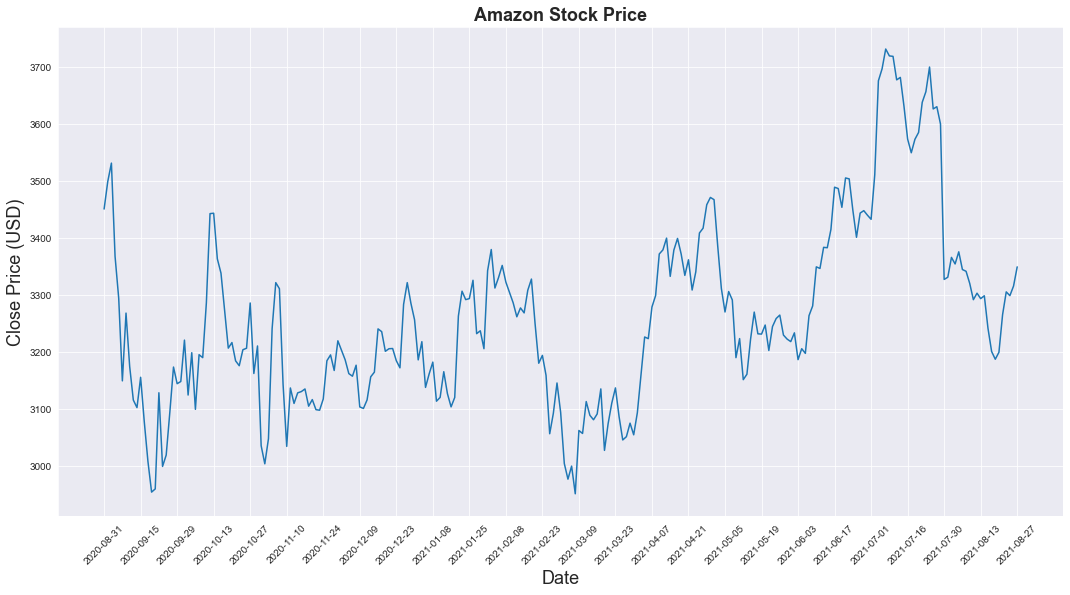

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.figure(figsize = (18,9))
plt.plot(data[['Close']])
plt.xticks(range(0,data.shape[0],10),data['Date'].loc[::10],rotation=45)
plt.title("Amazon Stock Price",fontsize=18, fontweight='bold')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price (USD)',fontsize=18)
plt.show()

## Normalize data

In [4]:
price = data[['Close']]
price.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 251 entries, 0 to 250
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   251 non-null    float64
dtypes: float64(1)
memory usage: 3.9 KB


In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
price['Close'] = scaler.fit_transform(price['Close'].values.reshape(-1,1))

C:\Windows\TEMP/ipykernel_9552/528903872.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price['Close'] = scaler.fit_transform(price['Close'].values.reshape(-1,1))


In [6]:
def split_data(stock, lookback):
    data_raw = stock.to_numpy() # convert to numpy array
    data = []
    
    # create all possible sequences of length seq_len
    for index in range(len(data_raw) - lookback): 
        data.append(data_raw[index: index + lookback])
    
    data = np.array(data)
    test_set_size = int(np.round(0.2*data.shape[0]))
    train_set_size = data.shape[0] - (test_set_size)
    
    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_train, y_train, x_test, y_test]

In [7]:
lookback = 20 # choose sequence length
x_train, y_train, x_test, y_test = split_data(price, lookback)
print('x_train.shape = ',x_train.shape)
print('y_train.shape = ',y_train.shape)
print('x_test.shape = ',x_test.shape)
print('y_test.shape = ',y_test.shape)

x_train.shape =  (185, 19, 1)
y_train.shape =  (185, 1)
x_test.shape =  (46, 19, 1)
y_test.shape =  (46, 1)


In [8]:
import torch
import torch.nn as nn

x_train = torch.from_numpy(x_train).type(torch.Tensor)
x_test = torch.from_numpy(x_test).type(torch.Tensor)
y_train_lstm = torch.from_numpy(y_train).type(torch.Tensor)
y_test_lstm = torch.from_numpy(y_test).type(torch.Tensor)
y_train_gru = torch.from_numpy(y_train).type(torch.Tensor)
y_test_gru = torch.from_numpy(y_test).type(torch.Tensor)

In [9]:
input_dim = 1
hidden_dim = 32
num_layers = 2
output_dim = 1
num_epochs = 250

In [10]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [11]:
model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss(reduction='mean')
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

In [12]:
import time

hist = np.zeros(num_epochs)
start_time = time.time()
lstm = []

for t in range(num_epochs):
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_lstm)
    print("Epoch ", t, "MSE: ", loss.item())
    hist[t] = loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
    
training_time = time.time()-start_time
print("Training time: {}".format(training_time))

Epoch  0 MSE:  0.3145851194858551
Epoch  1 MSE:  0.2152913212776184
Epoch  2 MSE:  0.12929248809814453
Epoch  3 MSE:  0.07592786103487015
Epoch  4 MSE:  0.17546145617961884
Epoch  5 MSE:  0.08604676276445389
Epoch  6 MSE:  0.07564888149499893
Epoch  7 MSE:  0.08678632229566574
Epoch  8 MSE:  0.09558509290218353
Epoch  9 MSE:  0.09873035550117493
Epoch  10 MSE:  0.09718464314937592
Epoch  11 MSE:  0.09244484454393387
Epoch  12 MSE:  0.08593565225601196
Epoch  13 MSE:  0.07904469966888428
Epoch  14 MSE:  0.0732530876994133
Epoch  15 MSE:  0.0701376274228096
Epoch  16 MSE:  0.07083025574684143
Epoch  17 MSE:  0.0739627256989479
Epoch  18 MSE:  0.07526222616434097
Epoch  19 MSE:  0.07286624610424042
Epoch  20 MSE:  0.06848296523094177
Epoch  21 MSE:  0.06448899954557419
Epoch  22 MSE:  0.06195956468582153
Epoch  23 MSE:  0.060714639723300934
Epoch  24 MSE:  0.06002047285437584
Epoch  25 MSE:  0.059087470173835754
Epoch  26 MSE:  0.05731942504644394
Epoch  27 MSE:  0.05445374175906181
Epoch

In [13]:
predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
original = pd.DataFrame(scaler.inverse_transform(y_train_lstm.detach().numpy()))

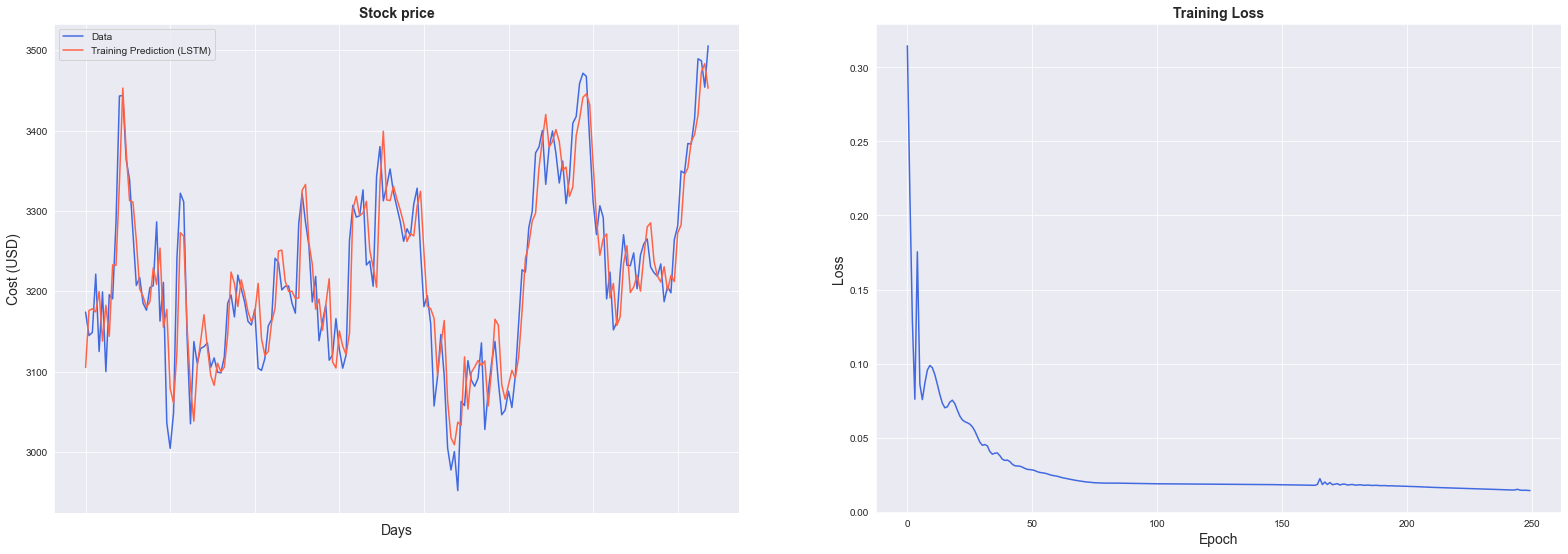

In [14]:
import seaborn as sns
sns.set_style("darkgrid")    

fig = plt.figure()
fig.subplots_adjust(hspace=0.2, wspace=0.2)

plt.subplot(1, 2, 1)
ax = sns.lineplot(x = original.index, y = original[0], label="Data", color='royalblue')
ax = sns.lineplot(x = predict.index, y = predict[0], label="Training Prediction (LSTM)", color='tomato')
ax.set_title('Stock price', size = 14, fontweight='bold')
ax.set_xlabel("Days", size = 14)
ax.set_ylabel("Cost (USD)", size = 14)
ax.set_xticklabels('', size=10)


plt.subplot(1, 2, 2)
ax = sns.lineplot(data=hist, color='royalblue')
ax.set_xlabel("Epoch", size = 14)
ax.set_ylabel("Loss", size = 14)
ax.set_title("Training Loss", size = 14, fontweight='bold')
fig.set_figheight(9)
fig.set_figwidth(27)

In [15]:
import math, time
from sklearn.metrics import mean_squared_error

# make predictions
y_test_pred = model(x_test)

# invert predictions
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler.inverse_transform(y_train_lstm.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler.inverse_transform(y_test_lstm.detach().numpy())

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
print('Test Score: %.2f RMSE' % (testScore))
lstm.append(trainScore)
lstm.append(testScore)
lstm.append(training_time)

Train Score: 46.50 RMSE
Test Score: 142.22 RMSE


In [16]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(price)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[lookback:len(y_train_pred)+lookback, :] = y_train_pred

# shift test predictions for plotting
testPredictPlot = np.empty_like(price)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(y_train_pred)+lookback-1:len(price)-1, :] = y_test_pred

original = scaler.inverse_transform(price['Close'].values.reshape(-1,1))

predictions = np.append(trainPredictPlot, testPredictPlot, axis=1)
predictions = np.append(predictions, original, axis=1)
result = pd.DataFrame(predictions)

In [17]:
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[0],
                    mode='lines',
                    name='Train prediction')))
fig.add_trace(go.Scatter(x=result.index, y=result[1],
                    mode='lines',
                    name='Test prediction'))
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[2],
                    mode='lines',
                    name='Actual Value')))
fig.update_layout(
    xaxis=dict(showline=True, showgrid=True, showticklabels=False, linecolor='white', linewidth=2),
    yaxis=dict(title_text='Close (USD)', 
        titlefont=dict(family='Rockwell', size=12, color='white'),
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='white',
        linewidth=2,
        ticks='outside',
        tickfont=dict(family='Rockwell', size=12, color='white')),
    showlegend=True,
    template = 'plotly_dark')

annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                        xanchor='left', yanchor='bottom',
                        text='Results (LSTM)',
                        font=dict(family='Rockwell',
                                  size=26,
                                  color='white'),
                                  showarrow=False))
fig.update_layout(annotations=annotations)
fig.show()

In [26]:
#import chart_studio.plotly as py
#import chart_studio
#chart_studio.tools.set_credentials_file(username='jsirgado', api_key='w2rVj5CXbO891JW8tGTC')
#py.iplot(fig, filename='stock_prediction_lstm')

In [18]:
class GRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn) = self.gru(x, (h0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [19]:
model = GRU(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss(reduction='mean')
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

In [20]:
hist = np.zeros(num_epochs)
start_time = time.time()
gru = []

for t in range(num_epochs):
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_gru)
    print("Epoch ", t, "MSE: ", loss.item())
    hist[t] = loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

training_time = time.time()-start_time    
print("Training time: {}".format(training_time))

Epoch  0 MSE:  0.24054282903671265
Epoch  1 MSE:  0.10868427157402039
Epoch  2 MSE:  0.08335527032613754
Epoch  3 MSE:  0.10567837953567505
Epoch  4 MSE:  0.08515353500843048
Epoch  5 MSE:  0.06895197182893753
Epoch  6 MSE:  0.07025053352117538
Epoch  7 MSE:  0.07346557825803757
Epoch  8 MSE:  0.06748856604099274
Epoch  9 MSE:  0.05521039664745331
Epoch  10 MSE:  0.046134233474731445
Epoch  11 MSE:  0.04729131609201431
Epoch  12 MSE:  0.048089686781167984
Epoch  13 MSE:  0.03874519094824791
Epoch  14 MSE:  0.0314050130546093
Epoch  15 MSE:  0.033729083836078644
Epoch  16 MSE:  0.036650579422712326
Epoch  17 MSE:  0.032691288739442825
Epoch  18 MSE:  0.028015948832035065
Epoch  19 MSE:  0.028929410502314568
Epoch  20 MSE:  0.030138961970806122
Epoch  21 MSE:  0.026800211519002914
Epoch  22 MSE:  0.023395612835884094
Epoch  23 MSE:  0.023104459047317505
Epoch  24 MSE:  0.024160701781511307
Epoch  25 MSE:  0.024157511070370674
Epoch  26 MSE:  0.022806255146861076
Epoch  27 MSE:  0.0214294

In [21]:
predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
original = pd.DataFrame(scaler.inverse_transform(y_train_gru.detach().numpy()))

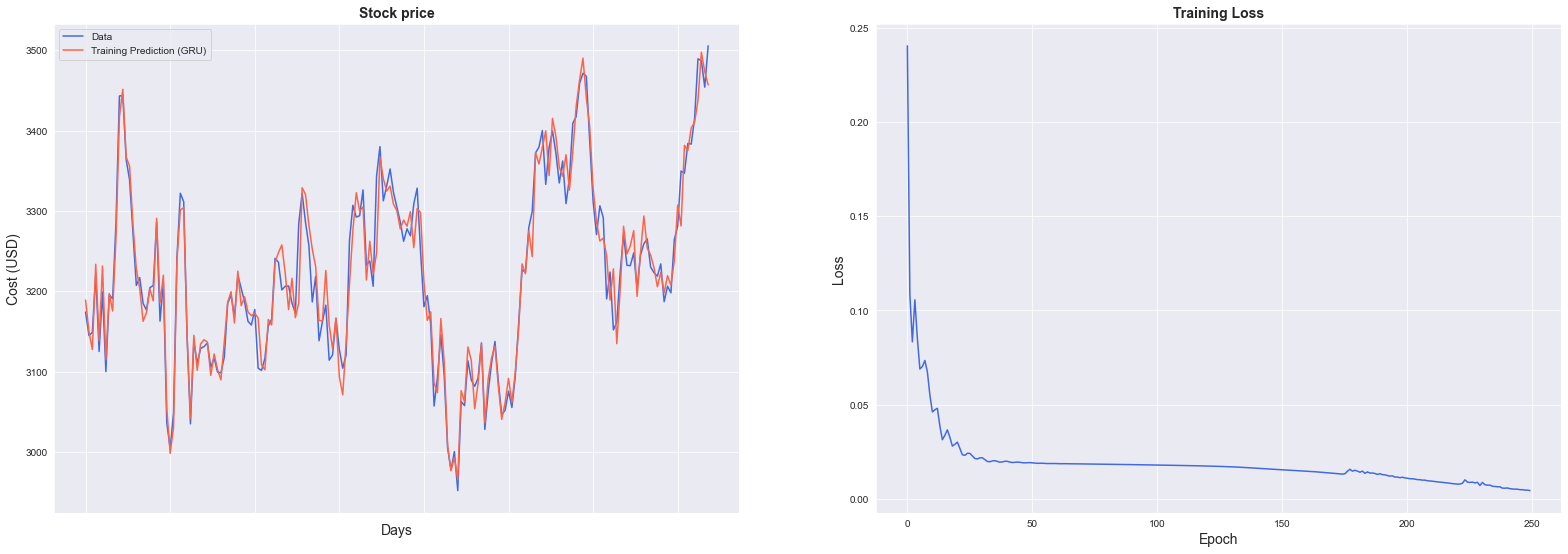

In [22]:
import seaborn as sns
sns.set_style("darkgrid")    

fig = plt.figure()
fig.subplots_adjust(hspace=0.2, wspace=0.2)

plt.subplot(1, 2, 1)
ax = sns.lineplot(x = original.index, y = original[0], label="Data", color='royalblue')
ax = sns.lineplot(x = predict.index, y = predict[0], label="Training Prediction (GRU)", color='tomato')
ax.set_title('Stock price', size = 14, fontweight='bold')
ax.set_xlabel("Days", size = 14)
ax.set_ylabel("Cost (USD)", size = 14)
ax.set_xticklabels('', size=10)


plt.subplot(1, 2, 2)
ax = sns.lineplot(data=hist, color='royalblue')
ax.set_xlabel("Epoch", size = 14)
ax.set_ylabel("Loss", size = 14)
ax.set_title("Training Loss", size = 14, fontweight='bold')
fig.set_figheight(9)
fig.set_figwidth(27)

In [23]:
import math, time
from sklearn.metrics import mean_squared_error

# make predictions
y_test_pred = model(x_test)

# invert predictions
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler.inverse_transform(y_train_gru.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler.inverse_transform(y_test_gru.detach().numpy())

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
print('Test Score: %.2f RMSE' % (testScore))
gru.append(trainScore)
gru.append(testScore)
gru.append(training_time)

Train Score: 25.84 RMSE
Test Score: 97.15 RMSE


In [24]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(price)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[lookback:len(y_train_pred)+lookback, :] = y_train_pred

# shift test predictions for plotting
testPredictPlot = np.empty_like(price)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(y_train_pred)+lookback-1:len(price)-1, :] = y_test_pred

original = scaler.inverse_transform(price['Close'].values.reshape(-1,1))

predictions = np.append(trainPredictPlot, testPredictPlot, axis=1)
predictions = np.append(predictions, original, axis=1)
result = pd.DataFrame(predictions)

In [25]:
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[0], mode='lines', name='Train prediction')))
fig.add_trace(go.Scatter(x=result.index, y=result[1], mode='lines', name='Test prediction'))
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[2], mode='lines', name='Actual Value')))
fig.update_layout(xaxis=dict(showline=True, showgrid=True, showticklabels=False, linecolor='white', linewidth=2),
                  yaxis=dict(title_text='Close (USD)', 
                     titlefont=dict(family='Rockwell', size=12, color='white'),
                     showline=True,
                     showgrid=True,
                     showticklabels=True,
                     linecolor='white',
                     linewidth=2,
                     ticks='outside',
                     tickfont=dict(family='Rockwell', size=12, color='white')),
                     showlegend=True,
                     template = 'plotly_dark')
annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05, xanchor='left', yanchor='bottom', text='Results (GRU)',
                        font=dict(family='Rockwell', size=26, color='white'),
                        showarrow=False))
fig.update_layout(annotations=annotations)
fig.show()

In [27]:
#py.iplot(fig, filename='stock_prediction_gru')

In [28]:
lstm = pd.DataFrame(lstm, columns=['LSTM'])
gru = pd.DataFrame(gru, columns=['GRU'])
result = pd.concat([lstm, gru], axis=1, join='inner')
result.index = ['Train RMSE', 'Test RMSE', 'Train Time']
result

,LSTM,GRU
Train RMSE,46.502811,25.838762
Test RMSE,142.219674,97.153305
Train Time,6.167471,5.320536
